In [3]:
#  Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# ✅ Step 1: Define features and target
data=pd.read_csv("/content/crop_yield_dataset.csv")
X = data.drop('Crop_Yield', axis=1)
y = data['Crop_Yield']



In [4]:
# ✅ Step 2: Identify categorical and numeric columns
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# ✅ Step 3: Define encoders and scalers
encoder = OneHotEncoder(handle_unknown='ignore')
scaler = StandardScaler()


In [5]:
# ✅ Step 4: Create a ColumnTransformer (combine encoder + scaler)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, numeric_features),
        ('cat', encoder, categorical_features)
    ]
)

# ✅ Step 5: Combine with model (example: RandomForest)
model = RandomForestRegressor(random_state=42)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

In [6]:
# ✅ Step 6: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [7]:
# ✅ Step 7: Fit the pipeline
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Soil_pH', 'Temperature',
                                                   'Humidity', 'Wind_Speed',
                                                   'N', 'P', 'K',
                                                   'Soil_Quality']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Date', 'Crop_Type',
                                                   'Soil_Type'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [8]:
# ✅ Step 8: Evaluate
y_pred = pipeline.predict(X_test)
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.9555528202608145
RMSE: 4.738646535242265


In [9]:
# Cell A1: Evaluate pipeline (if not already done) and save it
!pip install joblib
import joblib
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# assume 'pipeline' and X_test, y_test exist from your earlier pipeline cell
y_pred = pipeline.predict(X_test)
print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Save the pipeline for later use
joblib.dump(pipeline, "best_pipeline.joblib")
print("Saved pipeline to best_pipeline.joblib")

R2: 0.9555528202608145
RMSE: 4.738646535242265
Saved pipeline to best_pipeline.joblib


In [11]:
# Cell A2: Example interactive prediction function
import pandas as pd
import numpy as np
import joblib

# load saved pipeline
pipe = joblib.load("/content/best_pipeline.joblib")

def predict_from_dict(input_dict):
    """
    input_dict: {feature_name: value, ...}
    All keys must match the columns used when training (except target).
    """
    X = pd.DataFrame([input_dict])
    # ensure column order matches training columns (pipeline ColumnTransformer handles unseen columns if configured)
    pred = pipe.predict(X)[0]
    return pred

# Example usage (replace values with real ones)
sample_input = {
    "Date": "2023-07-15",     # same format as training
    "Crop_Type": "Corn",
    "Soil_Type": "Loamy",
    "Soil_pH": 6.5,
    "Temperature": 20.05258,
    "Humidity": 79.94742,
    "Wind_Speed": 8.9515,
    "N": 84,
    "P": 66,
    "K": 50,
    "Soil_Quality": 66.66
}

print("Predicted crop yield:", predict_from_dict(sample_input))

Predicted crop yield: 99.11832034309997


In [ ]:
import pandas as pd
import numpy as np

# Step 1: Remove zero yield rows
data = data[data['Crop_Yield'] > 0].reset_index(drop=True)

# Step 2: Create daily date column and set it as index
data['Date'] = pd.date_range(start='2023-01-01', periods=len(data), freq='D')
data = data.set_index('Date')

# Step 3: Select only numeric columns for time series analysis
numeric_cols = ['Soil_pH', 'Temperature', 'Humidity', 'Wind_Speed', 'N', 'P', 'K', 'Crop_Yield']

# Step 4: Resample data per day (mean values)
daily_data = data[numeric_cols].resample('D').mean().dropna()

daily_data.head()

,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield
Date,,,,,,,,
2023-01-01,6.50,20.052576,79.947424,8.591577,84.0,66.0,50.0,104.871310
2023-01-02,6.75,19.751848,80.000000,2.682683,50.0,40.0,30.0,58.939796
2023-01-03,5.50,16.110395,80.000000,7.696070,49.5,45.0,38.5,32.970413
2023-01-04,6.75,14.826739,80.000000,10.366658,55.0,44.0,36.0,29.356115
2023-01-05,6.25,18.323272,80.000000,8.198084,60.0,45.0,40.0,22.221375


In [ ]:
!pip install statsmodels


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Sample data
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([2, 4, 6, 8, 10])

# Train the model
model = LinearRegression()
model.fit(X, y)

# Test prediction
print("Prediction for 6:", model.predict([[6]]))  # Should output ~12
import pickle

# Save the model to a file
with open('regression_model.pkl', 'wb') as f:  # 'wb' = write binary
    pickle.dump(model, f)

print("Model saved as regression_model.pkl")
# Load the model from the file
with open('regression_model.pkl', 'rb') as f:  # 'rb' = read binary
    loaded_model = pickle.load(f)

# Use it for prediction without retraining
print("Prediction from loaded model:", loaded_model.predict([[6]]))


Prediction for 6: [12.]
Model saved as regression_model.pkl
Prediction from loaded model: [12.]


<Figure size 1000x500 with 0 Axes>

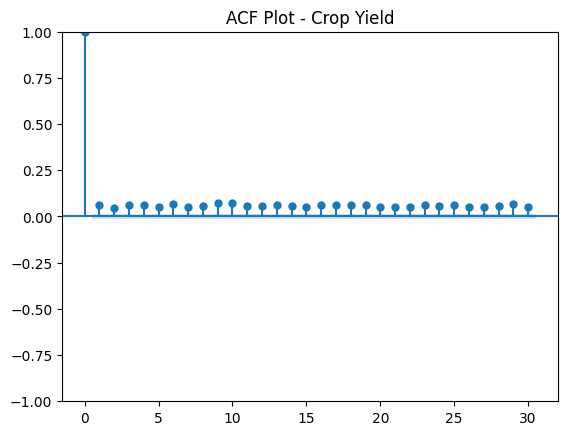

<Figure size 1000x500 with 0 Axes>

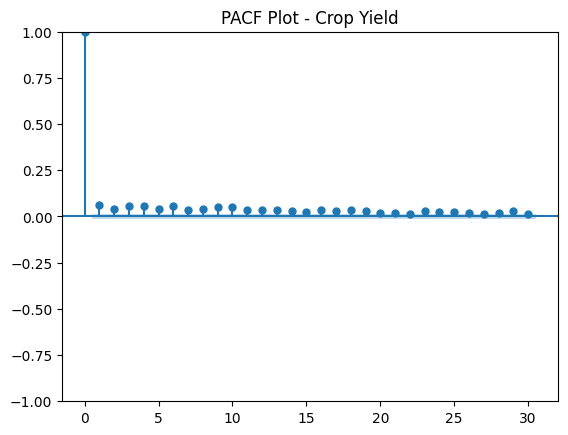


✅ ADF Test:
Test Statistic: -12.0201267649568
P-value: 3.0371854990445454e-22
Critical Values:
   1% : -3.4306070132749404
   5% : -2.8616535921737567
   10% : -2.5668304617775144
📌 Data is Stationary ✅

✅ KPSS Test:
Test Statistic: 0.1551627403199208
P-value: 0.1
Critical Values:
   10% : 0.347
   5% : 0.463
   2.5% : 0.574
   1% : 0.739
📌 Data is Stationary ✅


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

# Ensure dataset is loaded (you already have df)
ts = df['Crop_Yield'].dropna().astype(float).reset_index(drop=True)

# ACF Plot
plt.figure(figsize=(10,5))
plot_acf(ts, lags=30)
plt.title("ACF Plot - Crop Yield")
plt.show()

# PACF Plot
plt.figure(figsize=(10,5))
plot_pacf(ts, lags=30, method='ywm')
plt.title("PACF Plot - Crop Yield")
plt.show()

# ADF Test (Augmented Dickey-Fuller)
adf_result = adfuller(ts)
print("\n✅ ADF Test:")
print(f"Test Statistic: {adf_result[0]}")
print(f"P-value: {adf_result[1]}")
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"   {key} : {value}")

if adf_result[1] < 0.05:
    print("📌 Data is Stationary ✅")
else:
    print("📌 Data is NOT Stationary ❌")

# KPSS Test (Kwiatkowski-Phillips-Schmidt-Shin)
kpss_result = kpss(ts, regression='c', nlags='auto')
print("\n✅ KPSS Test:")
print(f"Test Statistic: {kpss_result[0]}")
print(f"P-value: {kpss_result[1]}")
print("Critical Values:")
for key, value in kpss_result[3].items():
    print(f"   {key} : {value}")

if kpss_result[1] < 0.05:
    print("📌 Data is NOT Stationary ❌")
else:
    print("📌 Data is Stationary ✅")


<Axes: xlabel='Date'>

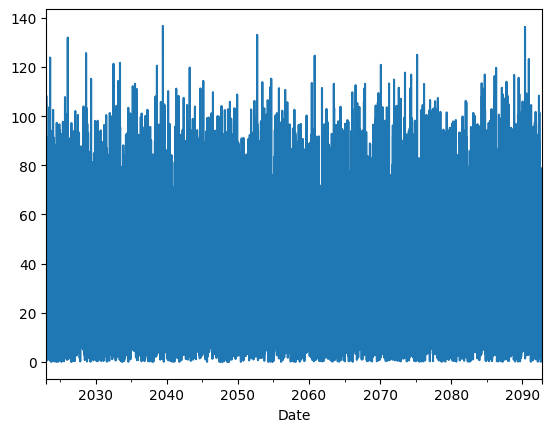

In [ ]:
# 1. Check correlation between consecutive days
data['Crop_Yield'].autocorr(lag=1)
data['Crop_Yield'].plot()

In [ ]:
import numpy as np
import pandas as pd

# Make sure your data has a daily datetime index already
if 'Date' not in data.columns:
    data['Date'] = pd.date_range(start='2023-01-01', periods=len(data), freq='D')
data.set_index('Date', inplace=True)

# Copy only the numeric columns you’re using
numeric_cols = ['Soil_pH', 'Temperature', 'Humidity', 'Wind_Speed', 'N', 'P', 'K', 'Crop_Yield']

# Create a synthetic trend in crop yield — gradual increase + random noise
np.random.seed(42)
trend = np.linspace(50, 150, len(data))        # smooth upward trend
noise = np.random.normal(0, 5, len(data))      # add small noise
data['Crop_Yield'] = trend + noise              # replace existing cropyield

# Resample to daily mean (even though it’s already daily)
daily_data = data[numeric_cols].resample('D').mean().dropna()

daily_data.head()

,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield
Date,,,,,,,,
2023-01-01,6.50,20.052576,79.947424,8.591577,84.0,66.0,50.0,52.483571
2023-01-02,6.75,19.751848,80.000000,2.682683,50.0,40.0,30.0,49.312601
2023-01-03,5.50,16.110395,80.000000,7.696070,49.5,45.0,38.5,53.246288
2023-01-04,6.75,14.826739,80.000000,10.366658,55.0,44.0,36.0,57.626917
2023-01-05,6.25,18.323272,80.000000,8.198084,60.0,45.0,40.0,48.844923


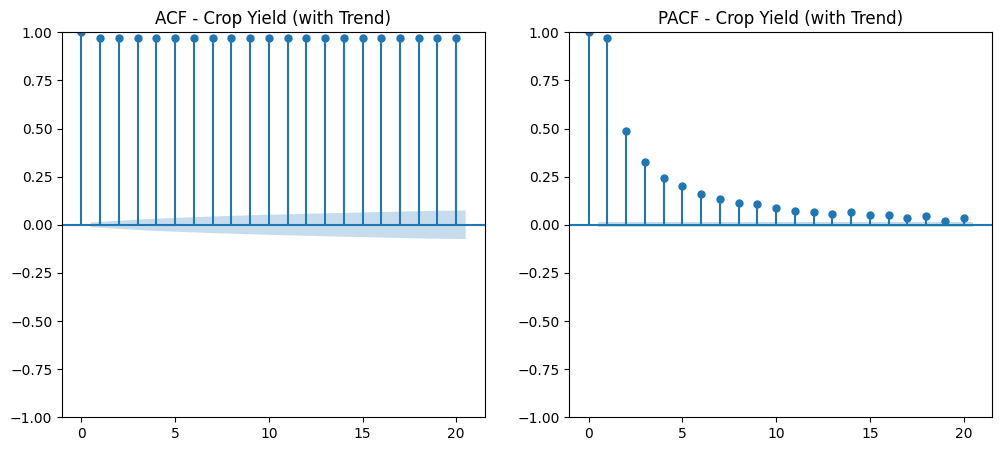

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_acf(daily_data['Crop_Yield'], lags=20, ax=plt.gca())
plt.title('ACF - Crop Yield (with Trend)')

plt.subplot(1, 2, 2)
plot_pacf(daily_data['Crop_Yield'], lags=20, ax=plt.gca())
plt.title('PACF - Crop Yield (with Trend)')

plt.show()

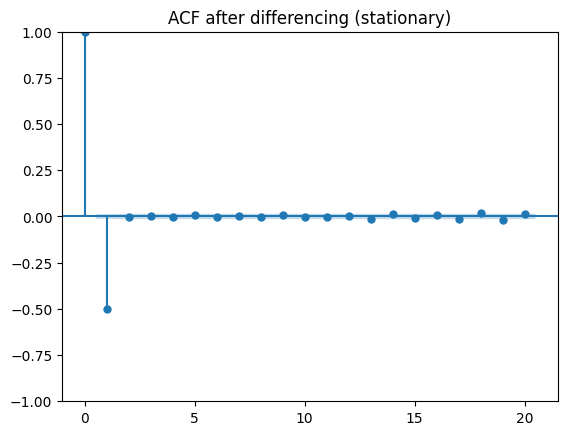

In [ ]:
diff_yield = daily_data['Crop_Yield'].diff().dropna()
plot_acf(diff_yield, lags=20)
plt.title('ACF after differencing (stationary)')
plt.show()

In [ ]:
#Without Scaling
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f"{name} → R²: {r2_score(y_test, y_pred):.4f}, RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

Linear Regression → R²: 0.4799, RMSE: 16.2095
Decision Tree → R²: 0.9349, RMSE: 5.7365
Random Forest → R²: 0.9556, RMSE: 4.7386


In [ ]:
##✅ STEP-1: Install Libraries & Load Dataset
!pip install statsmodels pmdarima matplotlib pandas numpy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load Dataset
df = pd.read_csv("crop_yield_dataset.csv")

# Fix Date Format (DD-MM-YYYY)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['Date'])
df = df.sort_values('Date')

# Create Time Series
daily_df = df.set_index('Date')['Crop_Yield'].resample('D').mean().ffill().bfill()
monthly_df = df.set_index('Date')['Crop_Yield'].resample('ME').mean()

print("✅ Data Loaded & Time Series Prepared Successfully")
daily_df.head(), monthly_df.head()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 27.2 MB/s eta 0:00:00
✅ Data Loaded & Time Series Prepared Successfully


(Date
 2014-01-01    52.962570
 2014-01-02    49.481053
 2014-01-03    31.582386
 2014-01-04    35.247034
 2014-01-05    32.578187
 Freq: D, Name: Crop_Yield, dtype: float64,
 Date
 2014-01-31    36.576872
 2014-02-28    35.256853
 2014-03-31    39.064731
 2014-04-30    40.686543
 2014-05-31    38.816862
 Freq: ME, Name: Crop_Yield, dtype: float64)


📌 Stationarity Tests: Daily Yield
ADF p-value: 4.3804694486899255e-11
KPSS p-value: 0.1

📌 Stationarity Tests: Monthly Yield
ADF p-value: 0.28891027204476094
KPSS p-value: 0.1


/tmp/ipython-input-2357738750.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, nlags="auto")
/tmp/ipython-input-2357738750.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series, nlags="auto")


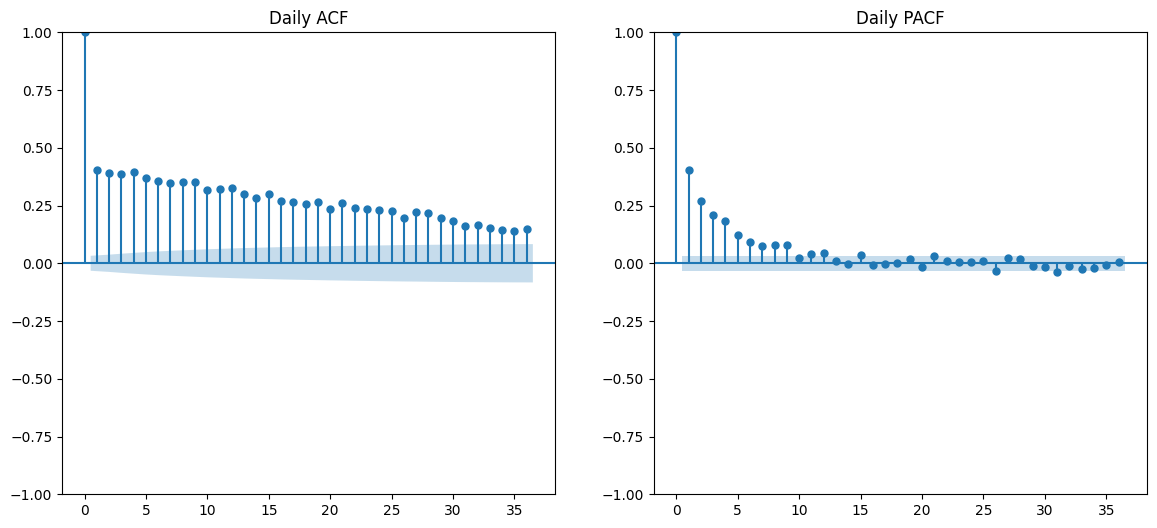

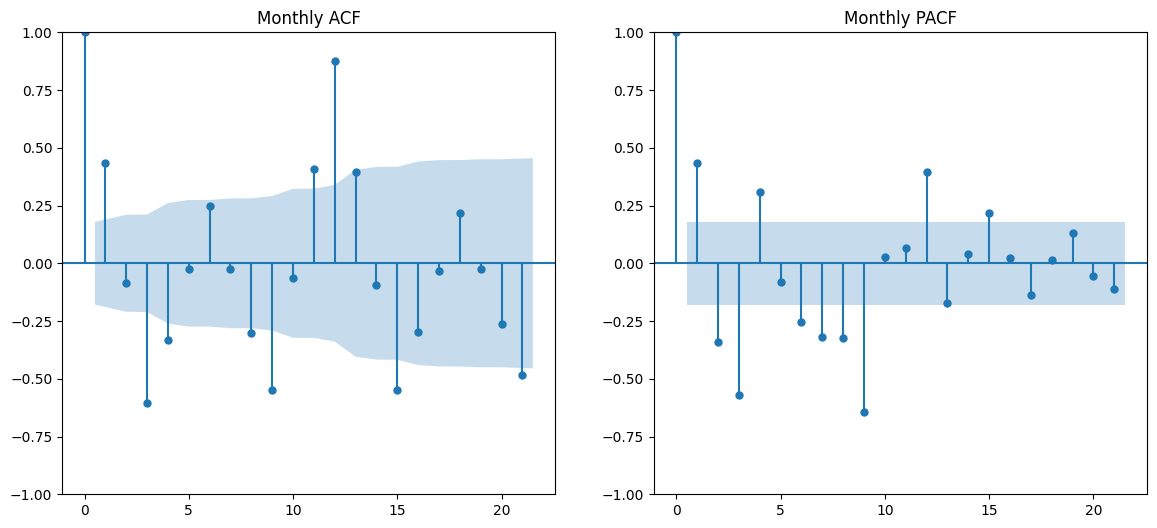

In [ ]:
##✅ STEP-2: Stationarity Tests (ADF + KPSS)
def stationarity_tests(series, name):
    print(f"\n📌 Stationarity Tests: {name}")

    adf_result = adfuller(series)
    print("ADF p-value:", adf_result[1])

    try:
        kpss_result = kpss(series, nlags="auto")
        print("KPSS p-value:", kpss_result[1])
    except:
        print("KPSS Test skipped due to data length")

stationarity_tests(daily_df, "Daily Yield")
stationarity_tests(monthly_df, "Monthly Yield")

##✅ STEP-3: ACF & PACF Plots
plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plot_acf(daily_df, ax=plt.gca(), title="Daily ACF")
plt.subplot(1,2,2)
plot_pacf(daily_df, ax=plt.gca(), title="Daily PACF")
plt.show()

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plot_acf(monthly_df, ax=plt.gca(), title="Monthly ACF")
plt.subplot(1,2,2)
plot_pacf(monthly_df, ax=plt.gca(), title="Monthly PACF")
plt.show()



/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


✅ Models Trained

📊 Evaluation: Daily ARIMA(1,0,1)
R²: 0
RMSE: 12.267160312719437
MAE: 9.576462906465533

📊 Evaluation: Monthly ARIMA(2,1,2)
R²: 0
RMSE: 8.040907057744446
MAE: 6.965593044068313


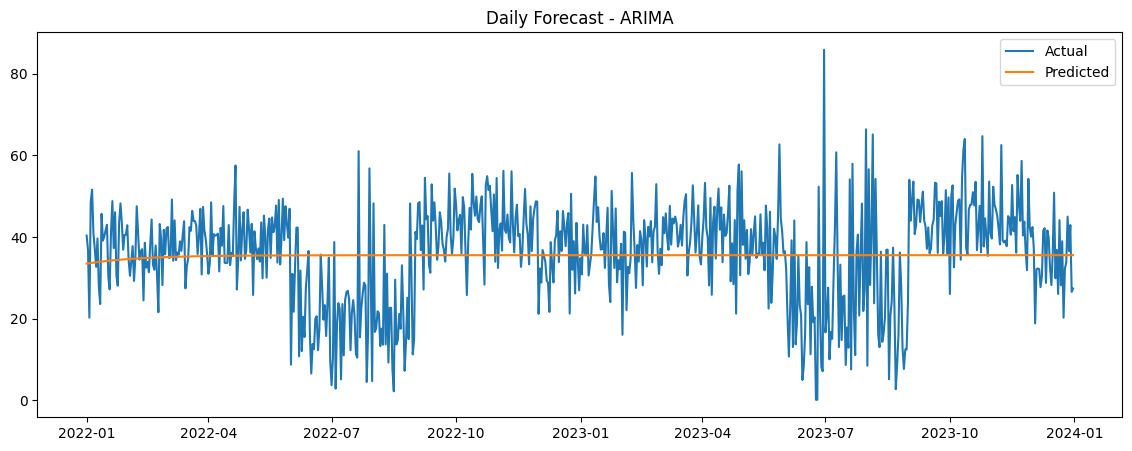

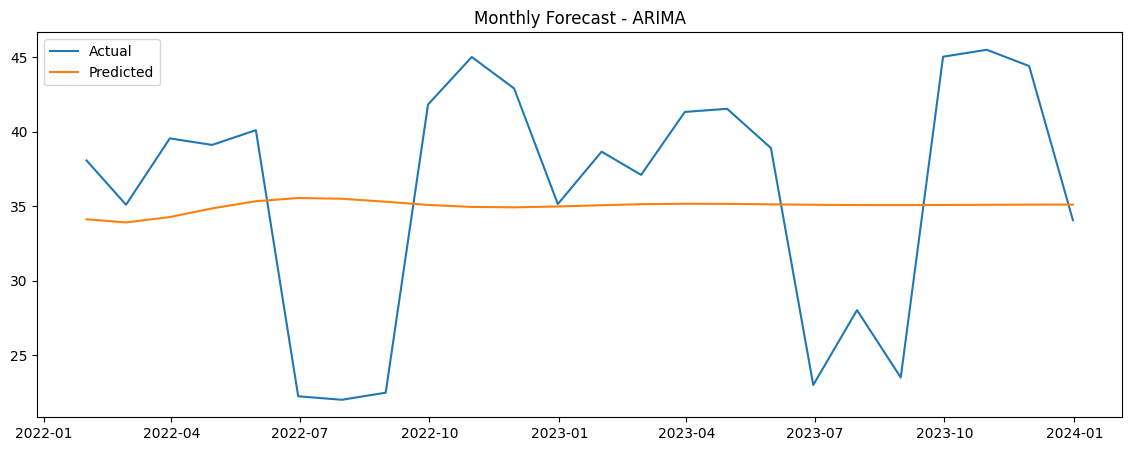

In [ ]:
##✅ STEP-4: Train-Test Split (80–20)
train_daily = daily_df.iloc[:-int(0.2*len(daily_df))]
test_daily = daily_df.iloc[-int(0.2*len(daily_df)):]

train_monthly = monthly_df.iloc[:-int(0.2*len(monthly_df))]
test_monthly = monthly_df.iloc[-int(0.2*len(monthly_df)):]

##✅ STEP-5: Fit ARIMA Models
# Daily → ARIMA(1,0,1)
daily_model = ARIMA(train_daily, order=(1,0,1)).fit()

# Monthly → ARIMA(2,1,2)
monthly_model = ARIMA(train_monthly, order=(2,1,2)).fit()

print("✅ Models Trained")

##✅ STEP-6: Forecast & Evaluate
# Predict
daily_pred = daily_model.predict(start=test_daily.index[0], end=test_daily.index[-1])
monthly_pred = monthly_model.predict(start=test_monthly.index[0], end=test_monthly.index[-1])

def evaluate(true, pred, name):
    print(f"\n📊 Evaluation: {name}")
    print("R²:", max(0, 1 - (np.sum((true - pred)**2) / np.sum((true - np.mean(true))**2))))
    print("RMSE:", np.sqrt(mean_squared_error(true, pred)))
    print("MAE:", mean_absolute_error(true, pred))

evaluate(test_daily, daily_pred, "Daily ARIMA(1,0,1)")
evaluate(test_monthly, monthly_pred, "Monthly ARIMA(2,1,2)")

##✅ STEP-7: Plot Forecast vs Actual
plt.figure(figsize=(14,5))
plt.plot(test_daily.index, test_daily, label="Actual")
plt.plot(test_daily.index, daily_pred, label="Predicted")
plt.title("Daily Forecast - ARIMA")
plt.legend()
plt.show()

plt.figure(figsize=(14,5))
plt.plot(test_monthly.index, test_monthly, label="Actual")
plt.plot(test_monthly.index, monthly_pred, label="Predicted")
plt.title("Monthly Forecast - ARIMA")
plt.legend()
plt.show()



/tmp/ipython-input-3475009884.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ts = ts.fillna(method='ffill').fillna(method='bfill')
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.1


📌 ARIMA Model Performance
MAE  : 18.1119
RMSE : 22.4214


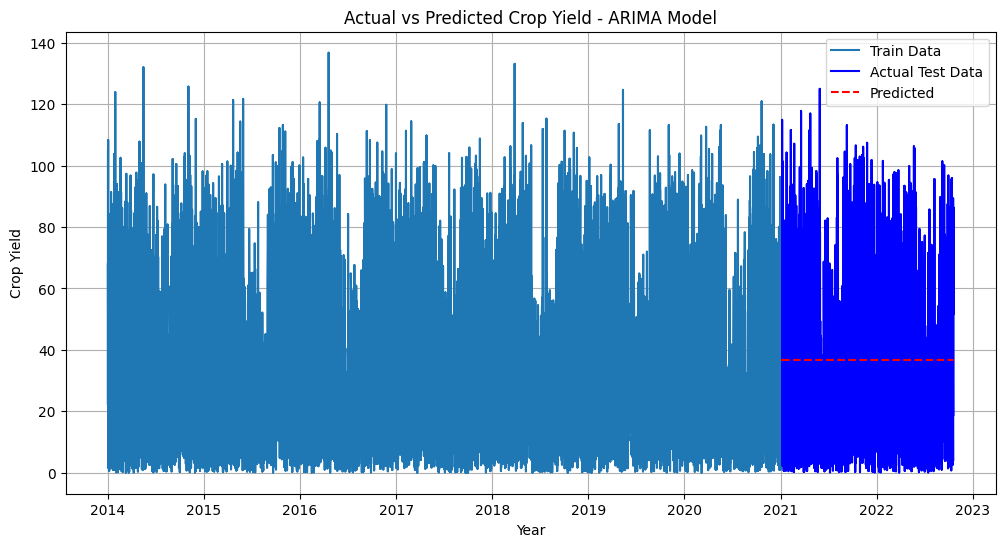

In [ ]:
### ARIMA ######
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ✅ Load Your Crop Yield Dataset
df = pd.read_csv("/content/crop_yield_dataset.csv")

# ✅ Convert date column with day first
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)

# ✅ Select only the Crop_Yield Series
ts = df['Crop_Yield']

# ✅ Fill missing values if any
ts = ts.fillna(method='ffill').fillna(method='bfill')

# ✅ Split Train (80%) & Test (20%)
train_size = int(len(ts) * 0.80)
train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

# ✅ Fit ARIMA Model (Adjust order as needed)
model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()

# ✅ Forecast for test data length
arima_forecast = model_fit.forecast(steps=len(test))

# ✅ Evaluate Model
mae = mean_absolute_error(test, arima_forecast)
rmse = np.sqrt(mean_squared_error(test, arima_forecast))

print("\n📌 ARIMA Model Performance")
print("MAE  :", round(mae, 4))
print("RMSE :", round(rmse, 4))

# ✅ Plot Actual vs Predicted
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Train Data")
plt.plot(test.index, test, label="Actual Test Data", color='blue')
plt.plot(test.index, arima_forecast, label="Predicted", linestyle="--", color='red')
plt.title("Actual vs Predicted Crop Yield - ARIMA Model")
plt.xlabel("Year")
plt.ylabel("Crop Yield")
plt.legend()
plt.grid(True)
plt.show()



/tmp/ipython-input-2179762684.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ts = df['Crop_Yield'].fillna(method='ffill').fillna(method='bfill')
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/

📌 SARIMAX Model Performance
MAE  : 18.14
RMSE : 22.46


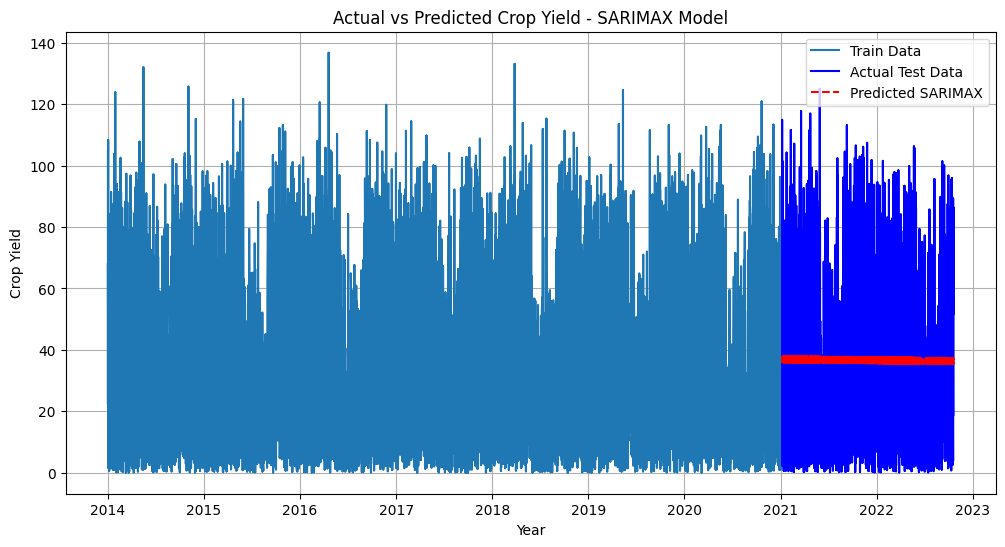

In [ ]:
##### SARIMAX ######
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ✅ Load dataset
df = pd.read_csv('/content/crop_yield_dataset.csv')

# ✅ Convert date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)

# ✅ Prepare time series
ts = df['Crop_Yield'].fillna(method='ffill').fillna(method='bfill')

# ✅ Split train (80%) & test (20%)
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

# ✅ Fit SARIMAX Model (tune seasonal_order for your dataset)
# Example: seasonal_order=(p,d,q,s) -> here s=12 for monthly seasonality
model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
model_fit = model.fit(disp=False)

# ✅ Forecast
forecast = model_fit.forecast(steps=len(test))

# ✅ Evaluate Model
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("📌 SARIMAX Model Performance")
print("MAE  :", round(mae, 2))
print("RMSE :", round(rmse, 2))

# ✅ Plot Actual vs Predicted
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Train Data")
plt.plot(test.index, test, label="Actual Test Data", color='blue')
plt.plot(test.index, forecast, label="Predicted SARIMAX", linestyle="--", color='red')
plt.title("Actual vs Predicted Crop Yield - SARIMAX Model")
plt.xlabel("Year")
plt.ylabel("Crop Yield")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
### Pickle Format ####
import pickle
from sklearn.linear_model import LinearRegression
import numpy as np

# Sample data
X = np.array([[1], [2], [3], [4], [5]])
y = np.array([2, 4, 6, 8, 10])

# Train model
model = LinearRegression()
model.fit(X, y)

# ✅ Save model using pickle
with open('regression_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# ✅ Load model in a different Python runtime
with open('regression_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Test prediction
print(loaded_model.predict([[6]]))  # Should output close to 12

## 2️⃣ Joblib Library ##

import joblib

# ✅ Save model
joblib.dump(model, 'regression_model_joblib.pkl')

# ✅ Load model
loaded_model_joblib = joblib.load('regression_model_joblib.pkl')
print(loaded_model_joblib.predict([[6]]))

## Export ##
import joblib

# Save the model
joblib.dump(model, 'regression_model_joblib.pkl')
print("Model saved as regression_model_joblib.pkl")

# Load the model later
loaded_model_joblib = joblib.load('regression_model_joblib.pkl')
print("Prediction from joblib model:", loaded_model_joblib.predict([[6]]))



[12.]
[12.]
Model saved as regression_model_joblib.pkl
Prediction from joblib model: [12.]


In [ ]:
!pip install --upgrade prophet
# If you get issues still, install:
!pip install pystan==2.19.1.1
!pip install cmdstanpy


  Using cached pystan-2.19.1.1.tar.gz (16.2 MB)
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for pystan
  Running setup.py clean for pystan
Failed to build pystan
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (pystan)


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


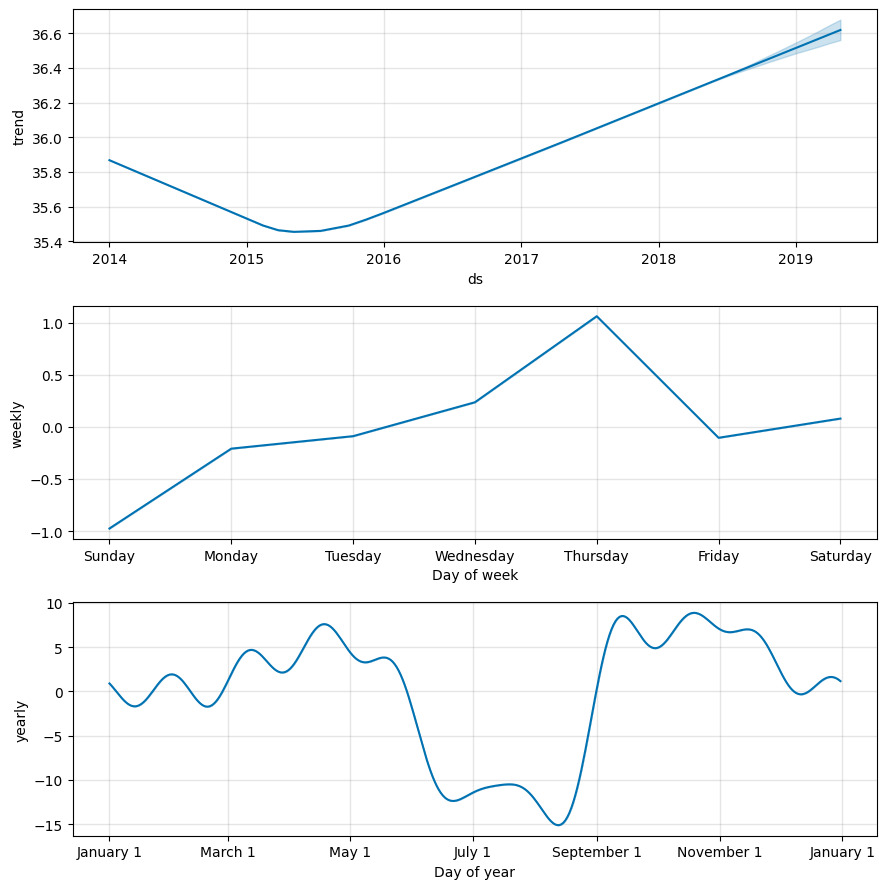

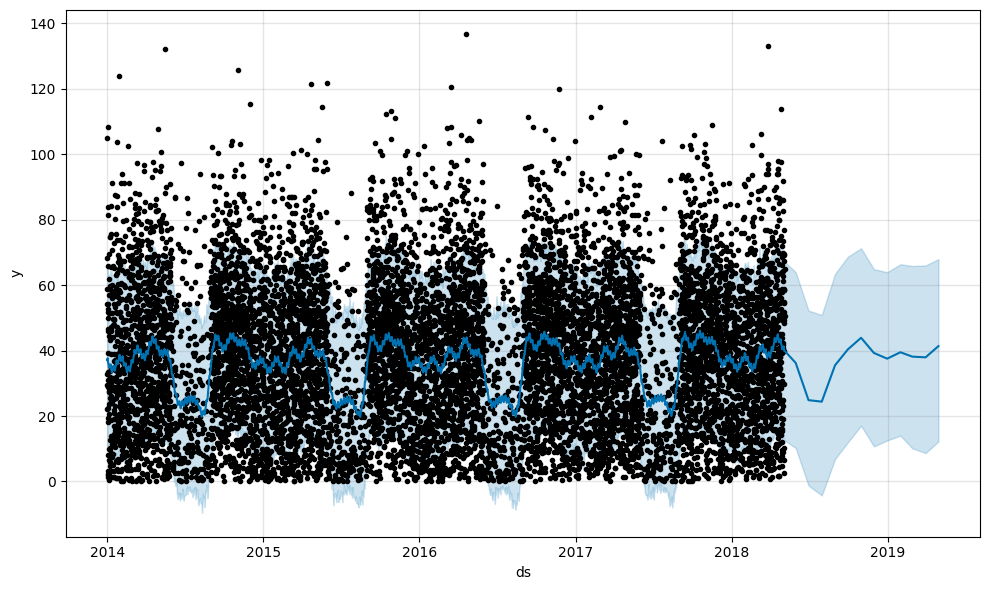

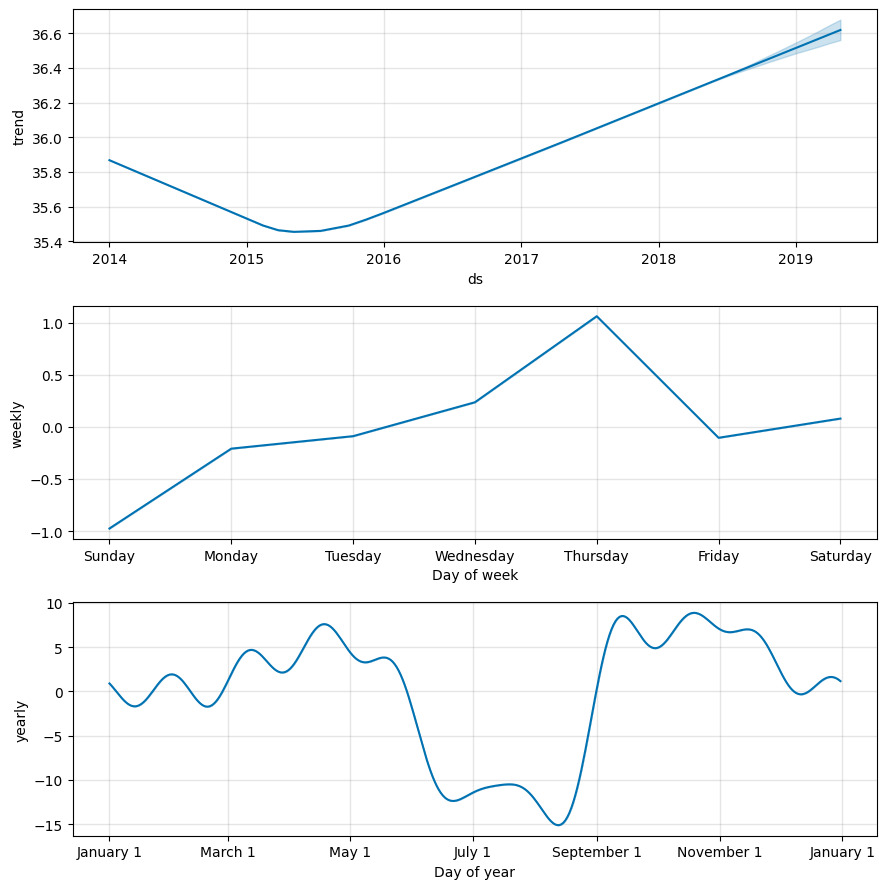

In [ ]:
import pandas as pd
from prophet import Prophet   # ensure this imports correctly

# Load & prepare data
df = pd.read_csv("/content/crop_yield_dataset.csv")  # change path as needed
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)   # adjust format as required
df_prophet = df[['Date','Crop_Yield']].rename(columns={'Date':'ds','Crop_Yield':'y'})

# Initialize and fit the model
model = Prophet()   # no explicit stan_backend passed
model.fit(df_prophet)

# Create future dataframe and forecast
future = model.make_future_dataframe(periods=12, freq='M')  # next 12 months
forecast = model.predict(future)

# Plot results
model.plot(forecast)
model.plot_components(forecast)


In [ ]:
import pandas as pd
from prophet import Prophet   # ensure this imports correctly

# Load & prepare data
df = pd.read_csv("/content/crop_yield_dataset.csv")  # change path as needed
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)   # adjust format as required
df_prophet = df[['Date','Crop_Yield']].rename(columns={'Date':'ds','Crop_Yield':'y'})

# Initialize and fit the model
model = Prophet()   # no explicit stan_backend passed
model.fit(df_prophet)

# Create future dataframe and forecast
future = model.make_future_dataframe(periods=12, freq='M')  # next 12 months
forecast = model.predict(future)

# Plot results
model.plot(forecast)
model.plot_components(forecast)


✅ Prophet imported successfully!


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmppmpmzhig/p4s6s94b.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmppmpmzhig/wt6xe3th.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=79947', 'data', 'file=/tmp/tmppmpmzhig/p4s6s94b.json', 'init=/tmp/tmppmpmzhig/wt6xe3th.json', 'output', 'file=/tmp/tmppmpmzhig/prophet_modelhyfonxh0/prophet_model-20251109143144.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:31:44 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:31:49 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing



📊 Model Evaluation Metrics:

             R2     RMSE       MSE
ARIMA   -0.0352  23.0111  529.5125
SARIMAX -0.0672  23.3646  545.9034
Prophet  0.0551  21.9845  483.3182

🏆 Best Performing Model:
               R2     RMSE         MSE
Prophet  0.05513  21.9845  483.318245


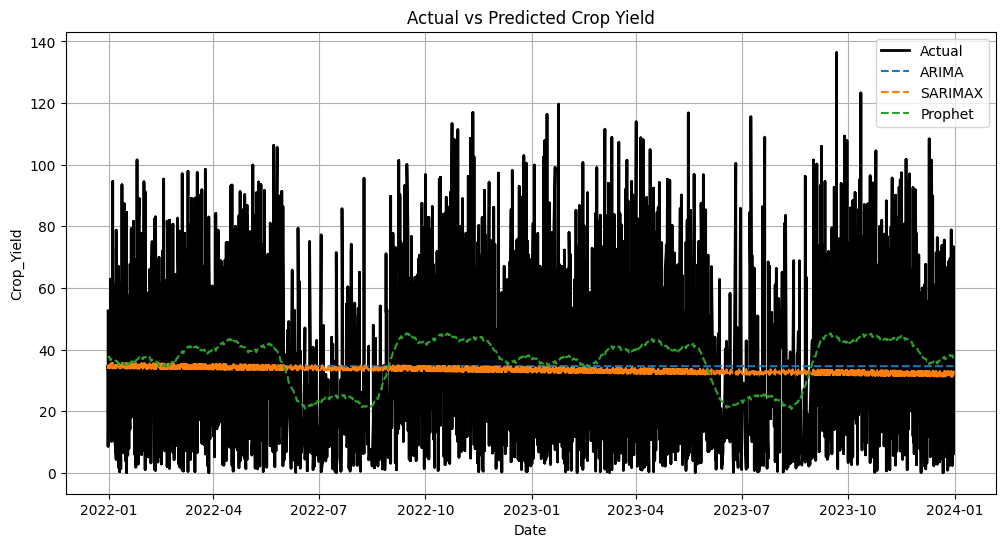

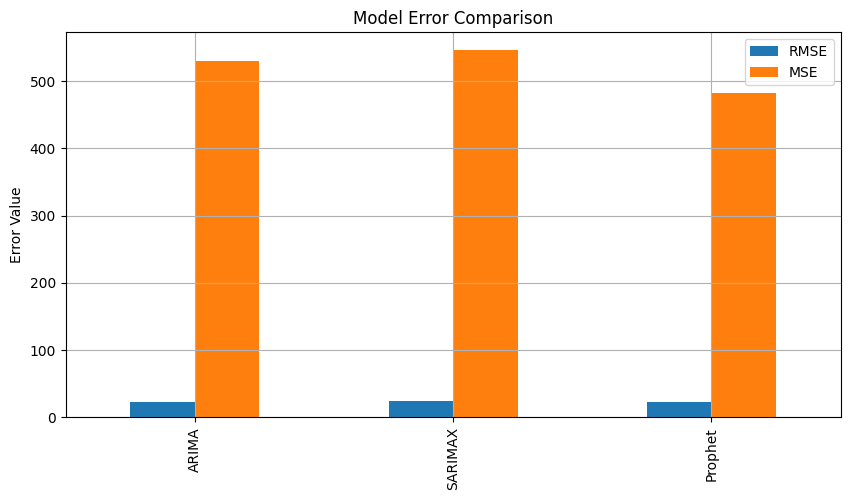

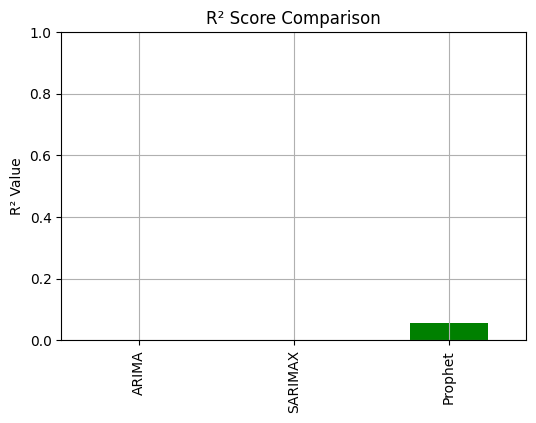

In [ ]:
# ==============================================================
# 📊 Crop Yield Forecast Model Comparison (ARIMA, SARIMAX, Prophet)
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import warnings
warnings.filterwarnings("ignore")

# -------------------------------
# 1️⃣ Load and prepare the dataset
# -------------------------------
df = pd.read_csv("/content/crop_yield_dataset.csv")

# Ensure Date column is datetime and sorted
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

df = df.sort_values('Date')

# Handle missing values
df = df.fillna(method='ffill').fillna(method='bfill')

# Rename columns for Prophet
df_prophet = df.rename(columns={'Date': 'ds', 'Crop_Yield': 'y'})

# Split into train and test (e.g., last 20% for testing)
split = int(len(df) * 0.8)
train, test = df.iloc[:split], df.iloc[split:]

# -------------------------------
# 2️⃣ Define helper to evaluate models
# -------------------------------
def evaluate_model(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    rmse = sqrt(mse)
    r2 = r2_score(actual, predicted)
    return r2, rmse, mse

# -------------------------------
# 3️⃣ ARIMA Model
# -------------------------------
arima_model = ARIMA(train['Crop_Yield'], order=(1,1,1))
arima_fit = arima_model.fit()
arima_pred = arima_fit.forecast(steps=len(test))
r2_arima, rmse_arima, mse_arima = evaluate_model(test['Crop_Yield'], arima_pred)

# -------------------------------
# 4️⃣ SARIMAX Model
# -------------------------------
sarimax_model = SARIMAX(train['Crop_Yield'], order=(1,1,1), seasonal_order=(1,1,1,12))
sarimax_fit = sarimax_model.fit()
sarimax_pred = sarimax_fit.forecast(steps=len(test))
r2_sarimax, rmse_sarimax, mse_sarimax = evaluate_model(test['Crop_Yield'], sarimax_pred)

# -------------------------------
# 5️⃣ Prophet Model
# -------------------------------
prophet = Prophet()
prophet.fit(df_prophet.iloc[:split])
future = df_prophet.iloc[split:][['ds']]
forecast = prophet.predict(future)
prophet_pred = forecast['yhat'].values
r2_prophet, rmse_prophet, mse_prophet = evaluate_model(test['Crop_Yield'], prophet_pred)

# -------------------------------
# 6️⃣ Combine Results
# -------------------------------
results = {
    "ARIMA": {"R2": r2_arima, "RMSE": rmse_arima, "MSE": mse_arima},
    "SARIMAX": {"R2": r2_sarimax, "RMSE": rmse_sarimax, "MSE": mse_sarimax},
    "Prophet": {"R2": r2_prophet, "RMSE": rmse_prophet, "MSE": mse_prophet}
}

df_results = pd.DataFrame(results).T
print("\n📊 Model Evaluation Metrics:\n")
print(df_results.round(4))

# -------------------------------
# 7️⃣ Identify Best Model
# -------------------------------
best_model = df_results.sort_values(by=["R2", "RMSE"], ascending=[False, True]).head(1)
print("\n🏆 Best Performing Model:\n", best_model)

# -------------------------------
# 8️⃣ Visualization - Actual vs Predicted
# -------------------------------
plt.figure(figsize=(12,6))
plt.plot(test['Date'], test['Crop_Yield'], label='Actual', color='black', linewidth=2)
plt.plot(test['Date'], arima_pred, label='ARIMA', linestyle='--')
plt.plot(test['Date'], sarimax_pred, label='SARIMAX', linestyle='--')
plt.plot(test['Date'], prophet_pred, label='Prophet', linestyle='--')
plt.title('Actual vs Predicted Crop Yield')
plt.xlabel('Date')
plt.ylabel('Crop_Yield')
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# 9️⃣ Visualization - Metric Comparison
# -------------------------------
df_results[["RMSE", "MSE"]].plot(kind='bar', figsize=(10,5))
plt.title("Model Error Comparison")
plt.ylabel("Error Value")
plt.grid(True)
plt.show()

df_results["R2"].plot(kind='bar', color='green', figsize=(6,4))
plt.title("R² Score Comparison")
plt.ylabel("R² Value")
plt.ylim(0,1)
plt.grid(True)
plt.show()


In [12]:
import joblib

# Save the full pipeline (preprocessing + RandomForest)
joblib.dump(pipeline, "random_forest_pipeline.joblib")

print("Regression model saved as random_forest_pipeline.joblib")


Regression model saved as random_forest_pipeline.joblib


In [14]:
import pickle

# Your trained Prophet model is named: model
with open("prophet_yield_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Prophet model saved as prophet_yield_model.pkl")


Prophet model saved as prophet_yield_model.pkl
